## Implementation of Averaged Perceptron in Python

- Will apply the classifier to [parkinsons data set](https://archive.ics.uci.edu/dataset/174/parkinsons)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('parkinsons.data')
#data.shape

X = data
X = X.drop(['status', 'name'], axis=1)
Xnames = X.columns.tolist()
X = X.values

T = data['status'].values
T = T.reshape((-1, 1))
Tname = 'status'

X.shape

(195, 22)

In [3]:
 Xnames

['MDVP:Fo(Hz)',
 'MDVP:Fhi(Hz)',
 'MDVP:Flo(Hz)',
 'MDVP:Jitter(%)',
 'MDVP:Jitter(Abs)',
 'MDVP:RAP',
 'MDVP:PPQ',
 'Jitter:DDP',
 'MDVP:Shimmer',
 'MDVP:Shimmer(dB)',
 'Shimmer:APQ3',
 'Shimmer:APQ5',
 'MDVP:APQ',
 'Shimmer:DDA',
 'NHR',
 'HNR',
 'RPDE',
 'DFA',
 'spread1',
 'spread2',
 'D2',
 'PPE']

In [4]:
T.shape, Tname

((195, 1), 'status')

In [5]:
np.unique(T)

array([0, 1])

In [6]:
T = np.where(T > 0, T, -1)

In [7]:
np.unique(T)

array([-1,  1])

In [8]:
uniq = np.unique(T)
print('   Value  Occurrences')
for i in uniq:
    print(f'{i:7.1g} {np.sum(T==i):10d}')

   Value  Occurrences
     -1         48
      1        147


In [9]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, Ttrain, Ttest = train_test_split(X, T, test_size=0.3, random_state=42, stratify=T )

In [10]:
print(f'Xtrain')
uniq = np.unique(Ttrain)
print('   Value  Occurrences')
for i in uniq:
    print(f'{i:7.1g} {np.sum(Ttrain == i):10d}')

    
print(f'Xtest')
uniq = np.unique(Ttest)
print('   Value  Occurrences')
for i in uniq:
    print(f'{i:7.1g} {np.sum(Ttest == i):10d}')


Xtrain
   Value  Occurrences
     -1         33
      1        103
Xtest
   Value  Occurrences
     -1         15
      1         44


In [11]:
def standardize(X):
    means = X.mean(0)
    stds = X.std(0)
    Xs = (X - means) / stds
    return Xs,means,stds

def insert_bias(X):
    Xs = np.insert(X , 0, 1, axis=1)
    return Xs

def use(X, W, means, stds):
    X = (X - means) / stds
    X = insert_bias(X)
    return X @ W.T

In [12]:
def train(X,T, lr):
    nIteration = 500
    n,d = X.shape
    W = np.zeros((1,d))
    aW = np.zeros((1,d))
    rng = np.random.default_rng(seed=30)
    index = np.arange(n)
    
    
    for step in range(nIteration):
        
        np.random.shuffle(index)
        
        for i in range(X.shape[0]):

            ix = index[i]
            
            pred = X[ix, :] @ W.T

            if T[ix] * pred <= 0:
                W +=  lr * X[ix, :] * T[ix,:]
        
        aW = aW + W

    return aW
            
  
    

In [13]:
Xtr,means,stds = standardize(Xtrain)
Xtr = insert_bias(Xtr)

aW = train(Xtr, Ttrain, 1)

In [14]:
train_pred = Xtr * aW

test_pred = use(Xtest, aW, means,stds)

In [15]:
print(f'Accuracy = {np.sum(np.sign(test_pred) == np.sign(Ttest)) / Ttest.shape[0] * 100:.2f}%')

Accuracy = 81.36%


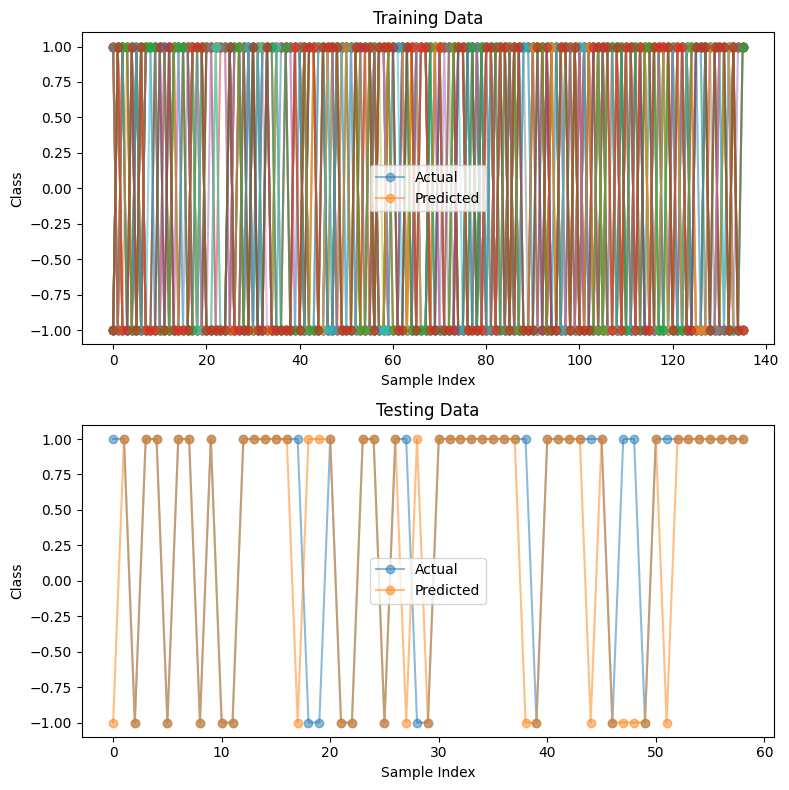

In [16]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1 ,1)
plt.plot(np.hstack((np.sign(Ttrain), np.sign(train_pred))), 'o-', alpha=0.5)
plt.xlabel('Sample Index')
plt.ylabel('Class')
plt.title('Training Data')
plt.legend(('Actual', 'Predicted'), loc='center')


plt.subplot(2, 1, 2)
plt.plot(np.hstack((np.sign(Ttest), np.sign(test_pred))), 'o-', alpha=0.5)
plt.xlabel('Sample Index')
plt.ylabel('Class')
plt.title('Testing Data')
plt.legend(('Actual', 'Predicted'), loc='center');

plt.tight_layout()